<a href="https://colab.research.google.com/github/SeloJumadiko/-data-science-2026/blob/main/Pertemuan10_%5BSelo_Jumadiko%5D_%5B240401010276%5D_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama Lengkap : Selo Jumadiko

NIM : 240401010276

Kelas : IF403

In [8]:
# Muat dan Eksplorasi data
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(path)
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Ukuran Dataset:", df.shape)
print("\nProporsi Target (Churn):")
print(df["Churn"].value_counts(normalize=True))

from sklearn.model_selection import train_test_split

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn
Ukuran Dataset: (7043, 21)

Proporsi Target (Churn):
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [9]:
# Preprosesing
from sklearn.model_selection import train_test_split

# Memisahkan X (fitur) dan y (target = Churn)
if df["Churn"].dtype == 'object':
    y = df["Churn"].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
else:
    y = df["Churn"]
X = df.drop(columns=["Churn"])

# Encoding fitur kategorikal
X = pd.get_dummies(X, drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
# Latih Model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42
)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [11]:
# Evaluasi
from sklearn.metrics import classification_report, roc_auc_score

# Menghitung prediksi dan probabilitas
y_pred = rf.predict(X_te)

In [12]:
# Menghitung probabilitas churn (predict_proba)
y_prob = rf.predict_proba(X_te)[:, 1]

In [13]:
# Menampilkan classification_report dan ROC-AUC
print("\n=== Classification Report ===")
print(classification_report(y_te, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}")


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8337


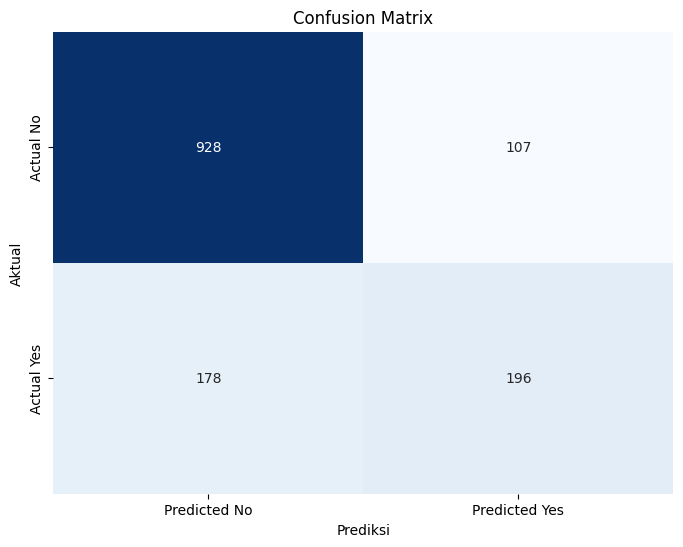

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung Confusion Matrix
cm = confusion_matrix(y_te, y_pred)

# Membuat visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

1. Penyeimbangan bobot kelas (class_weight='balanced') pada model Random Forest sangat penting karena proporsi data awal menunjukkan adanya ketidakseimbangan kelas target (imbalanced data).
2. Evaluasi menggunakan kombinasi Classification Report dan skor ROC-AUC memberikan gambaran objektif mengenai sensitivitas model serta kemampuannya dalam memisahkan pelanggan yang berisiko churn dengan yang tidak.
3. Output probabilitas dari 'predict_proba' memberikan nilai risiko yang kontinu.

Kesimpulan pada Pertemuan ke 10 adalah mempelajari cara memprediksi churn pelanggan menggunakan dataset 'telco-customer-churn'. Dimana proses yang dilakukan meliputi pemuatan data, eksplorasi awal untuk memahami proporsi churn, pra-pemrosesan data, pembagian data menjadi set pelatihan dan pengujian, pelatihan model klasifikasi Random Forest dengan penyeimbangan kelas, dan evaluasi model menggunakan *Classification Report*, skor ROC-AUC, serta *Confusion Matrix*.

Temuan utama pada Pertemuan 10
*   Ketidakseimbangan Kelas: Dataset menunjukkan ketidakseimbangan kelas yang signifikan, dengan mayoritas pelanggan tidak churn (sekitar 73%) dan minoritas yang churn (sekitar 27%).
*   Kinerja Model: Model Random Forest mencapai akurasi keseluruhan sekitar 80% dan skor ROC-AUC 0.8337.
*   Confusion Matrix: Dari Confusion Matrix, terlihat bahwa model cenderung lebih baik dalam memprediksi pelanggan yang tidak akan churn (928 True Negatives). Namun, model masih memiliki sejumlah False Negatives (178), artinya ada 178 pelanggan yang sebenarnya churn tetapi diprediksi tidak churn oleh model. Sedangkan untuk True Positives (196), model berhasil mengidentifikasi 196 pelanggan yang benar-benar churn.
*   Recall untuk Churn: Recall untuk kelas 'Yes' (churn) adalah 0.52, yang berarti model berhasil menangkap sekitar 52% dari semua pelanggan yang